# Knee Injuries Classification Project
## MRNet Classifier Notebook 

### Data source: 
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [1]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import sys
import os
import zipfile
import shutil

### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code. 

In [43]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder
# since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
shared_folder_path = '/content/drive/MyDrive/mrnet_images' 

# DESTINATION: The local, ultra-fast Colab cloud SSD storage
local_zip_path = '/content/mrnet_images.zip'

print("Starting optimized compression onto local cloud SSD...")

# 2. Zip from Drive directly to the local cloud SSD
!zip -rq "{local_zip_path}" "{shared_folder_path}"

print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# 3. Copy the single large zip back to Google Drive in one efficient burst
!cp "{local_zip_path}" "/content/drive/MyDrive/"

print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting optimized compression onto local cloud SSD...


zip error: Interrupted (aborting)
Compression to local SSD complete! Now uploading the single file back to your Drive...
cp: cannot stat '/content/mrnet_images.zip': No such file or directory
All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.


### Loading data into colab SSD 
When we already have your zip folder, we can start from here to git the data unziped inside the colab SSD. 

In [2]:
# 1. Mount persistent storage
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

# Define our paths clearly
zip_source = '/content/drive/MyDrive/mrnet_images.zip'
zip_local = '/content/mrnet_images.zip'
extract_to = '/content/'

# 2. Run extraction sequence if data isn't unpacked yet
if not os.path.exists('/content/mrnet_images'):
    
    # Step A: Copy the zip from Drive to local SSD if it's missing
    if not os.path.exists(zip_local):
        print("Transferring optimized archive from Drive to local cloud SSD...")
        shutil.copy(zip_source, zip_local)
        print("Transfer complete! Starting extraction...")
        
    # Step B: Unzip with the visible progress counter
    print("Opening zip archive securely...")
    with zipfile.ZipFile(zip_local, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        print(f"Total files to extract: {total_files}")
        
        for index, file in enumerate(files):
            zip_ref.extract(file, extract_to)
            if index % 500 == 0 and index > 0:
                print(f"-> Extracted {index}/{total_files} files... ({int(index/total_files*100)}%)")
                
    print("Unpacking complete!")
    
    # Step C: Fix the path nesting structure automatically
    if os.path.exists('/content/content/drive/MyDrive/mrnet_images'):
        print("Correcting zip path nesting structure...")
        os.rename('/content/content/drive/MyDrive/mrnet_images', '/content/mrnet_images')
        shutil.rmtree('/content/content')
        
    # Step D: Clean up the local zip file to save SSD space
    if os.path.exists(zip_local):
        os.remove(zip_local)
        
    print("Environment Setup Perfected!")
else:
    print("Data already unpacked and ready on local SSD.")

Transferring optimized archive from Drive to local cloud SSD...
Transfer complete! Starting extraction...
Opening zip archive securely...
Total files to extract: 3580
-> Extracted 500/3580 files... (13%)
-> Extracted 1000/3580 files... (27%)
-> Extracted 1500/3580 files... (41%)
-> Extracted 2000/3580 files... (55%)
-> Extracted 2500/3580 files... (69%)
-> Extracted 3000/3580 files... (83%)
-> Extracted 3500/3580 files... (97%)
Unpacking complete!
Correcting zip path nesting structure...
Environment Setup Perfected!


### Importing .py file

In [11]:
import importlib
# 1. Clone the repository if it doesn't exist on the cloud machine yet
repo_path = '/content/CNN_ClassModeling'

if not os.path.exists(repo_path):
    print("Cloning the code repository from GitHub...")
    !git clone https://github.com/AbdulAlbaqami/Knee_Injuries_Classification_Model_MRI_Images.git {repo_path}
else:
    print("Repository already exists. Pulling latest updates...")
    !cd {repo_path} && git pull

# 2. Inject the repository path into Python's system search path
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 3. Safe Module Import / Reload Logic
import loading_data as ld
# If teammates update the file and you pull it, this line forces Python to update its cache
importlib.reload(ld)

print("Successfully imported loading_data.py module!")

Cloning the code repository from GitHub...
Cloning into '/content/CNN_ClassModeling'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 18 (delta 5), reused 15 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 527.54 KiB | 5.07 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Hello World
Hello World
Successfully imported loading_data.py module!


In [4]:
import numpy as np

# Load a single case 
sample_volume = np.load('/content/mrnet_images/axial/0001.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (30, 256, 256)


Array Shape: (26, 256, 256)


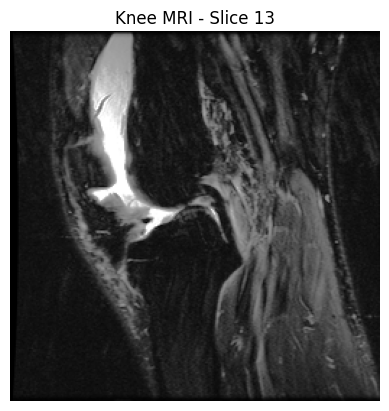

In [5]:
import matplotlib.pyplot as plt

# 1. Load one of your downloaded files (replace with your actual file path)
# Let's grab a random one from your sagittal or axial folder
mri_volume = np.load('/content/mrnet_images/sagittal/0001.npy')

# 2. Check its dimensions
print("Array Shape:", mri_volume.shape)

# 3. Visualize a slice from the middle of the stack
middle_slice_idx = mri_volume.shape[0] // 2

plt.imshow(mri_volume[middle_slice_idx], cmap="gray")
plt.axis("off")
plt.title(f"Knee MRI - Slice {middle_slice_idx}")
plt.show()

### labels Data EDA

In [6]:
import pandas as pd
label_data = pd.read_csv("/content/mrnet_images/labels/Redivis-files-2026-05-18.csv")
print(label_data.head())
print(label_data.columns)
print(label_data["Folder"].value_counts())
print(label_data.describe())


             Name Folder
0  axial/0000.npy  train
1  axial/0001.npy  train
2  axial/0002.npy  train
3  axial/0003.npy  train
4  axial/0004.npy  train
Index(['Name', 'Folder'], dtype='object')
Folder
train    3390
valid     360
Name: count, dtype: int64
                     Name Folder
count                3750   3750
unique               3750      2
top     sagittal/1249.npy  train
freq                    1   3390


# MOdeling: 
## 1 Multi-Task Model

### Environment Orchestration & Data Loading

In [1]:
import sys
import torch
import torch.nn as nn
from torchvision import models
import importlib

# 1. Hardware-Agnostic Device Selection
if torch.cuda.is_available():
    device = torch.device("cuda") # Triggers on Google Colab
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Triggers locally on your M4 Pro
else:
    device = torch.device("cpu")
    
print(f"Active compute device: {device}")

# 2. Safely import our data pipeline
try:
    import loading_data as ld
    importlib.reload(ld)
except ModuleNotFoundError:
    # If running on Colab, ensure the repo path is added
    sys.path.append('/content/CNN_ClassModeling')
    import loading_data as ld

# 3. Initialize the DataLoader using our local test path
# CHANGE LOCAL_ROOT to your exact mrnet_images path for the local test
LOCAL_ROOT = "./mrnet_images" 
LABEL_PATH = "./unified_labels.csv"

train_loader, valid_loader = ld.get_data_loaders(LOCAL_ROOT, LABEL_PATH, view='sagittal', batch_size=1)
print("Data pipeline initialized and ready.")

Active compute device: mps
Data pipeline initialized and ready.


### The Multi-Task Baseline Architecture (Tier 1)

In [ ]:
class MRNetBaseline(nn.Module):
    def __init__(self):
        super(MRNetBaseline, self).__init__()
        
        # 1. The 2D Feature Extractor (Backbone)
        # Load a pre-trained AlexNet
        alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        
        # We only want the convolutional feature extractor, not its original 1000-class head
        self.features = alexnet.features 
        
        # 2. The Multi-Task Classification Head
        # AlexNet's feature map flattens out to a 256 * 7 * 7 = 12544 vector
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 7 * 7, 3) # 3 outputs: Abnormal, ACL, Meniscus
        )

    def forward(self, x):
        # x arrives as a 5D tensor: [Batch=1, Slices=S, Channels=3, H=256, W=256]
        
        # TRICK: We squeeze out the Batch dimension of 1.
        # Now x is [S, 3, 256, 256]. PyTorch will think we are passing a batch of S images!
        x = x.squeeze(0) 
        
        # 1. Extract features for all S slices simultaneously
        # Output shape becomes [S, 256, 7, 7]
        features = self.features(x)
        
        # Flatten the spatial dimensions: [S, 12544]
        features = torch.flatten(features, 1)
        
        # 2. Global Max Pooling across the Slice dimension (dim=0)
        # This squashes [S, 12544] down to a single knee vector [12544]
        pooled_features, _ = torch.max(features, dim=0)
        
        # We unsqueeze to add the batch dimension back: [1, 12544]
        pooled_features = pooled_features.unsqueeze(0)
        
        # 3. Pass the unified vector to the multi-task head
        # Output shape: [1, 3] containing the raw logits for our 3 diagnoses
        logits = self.classifier(pooled_features)
        
        return logits